# Final Model Run
In *modeling_additional_labs.ipynb*, we used `GridSearchCV` to perform 5-fold cross-validation for a variety of different feature combinations. Based on the results obtained in that notebook, we concluded that our best model (that does not use creatinine as a feature) uses `LogisticRegression` with features: albumin, bun, and bicarbonate. This model achieved an accuracy score on the training set of 85.59% along with a false negative rate on the training set of 18.36%. The objective of this notebook is to now evaluate the best model on the test set as a final sanity check and to confirm that the model is expected to generalize reasonably well. For the purpose of comparison, we also evaluate a `LogisticRegression` model that uses creatinine as the only feature on the test set. In 5-fold cross-validation (on the training set), this model achieved an accuracy score and false negative rate of 92.47% and 11.15%, respectively. Our goal is for the results obtained using the best model to be as close as possible to the results obtained using the creatinine model.

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [18]:
data_train = pd.read_csv('../Data/data_train_scaled.csv')
data_test = pd.read_csv('../Data/data_test_scaled.csv')
data_train.head()

,subject_id,albumin,bicarbonate,calcium,chloride,creatinine,potassium,bun,hemoglobin,class,bun_over_creatinine
0,16882027,-0.306097,-0.219144,-0.328880,-0.845924,-0.249272,0.081285,-0.224058,-0.223042,1,-0.055262
1,10008304,0.910988,-0.856747,-0.214185,0.312212,-0.477018,-0.356937,-0.004527,1.570660,0,1.432929
2,10048451,1.587147,0.205925,0.818071,-0.349580,-0.533954,-0.210863,-0.663121,0.374859,0,-0.111209
3,10049330,-0.170866,0.843529,0.703376,0.808556,-0.590891,0.081285,-0.663121,1.100881,0,0.179716
4,11757006,0.775757,0.418460,0.588681,-0.349580,-0.135399,5.193882,-0.136246,0.118616,1,-0.178345


### Naive Baseline: Random Coin Flip (see problem session 8)

In [19]:
random_acc = []
random_fn = []
for n in range(1000):
    draw = np.random.binomial(n = 1,
                             p = np.max(data_test['class'].value_counts(normalize = True)),
                             size = data_test.shape[0])
    cm = confusion_matrix(data_test[target],
                         draw)
    random_acc.append(accuracy_score(data_test[target],
                                    draw))
    random_fn.append(cm[1, 0]/(cm[1, 0] + cm[1, 1]))
print('The accuracy score for the naive baseline is', np.mean(random_acc))
print('The false negative rate for the naive baseline is', np.mean(random_fn))

The accuracy score for the naive baseline is 0.49783660130718954
The false negative rate for the naive baseline is 0.4971818181818181


### Best Model (Features: albumin, bun, bicarbonate)

The best hyperparameter values were {'C': 10}
The best average cross-validation accuracy was 0.8558976409436225
The false negative rate on the training data was 0.18360655737704917


The accuracy on the test set was 0.8431372549019608
The false negative rate on the test data was 0.23376623376623376


NameError: name 'plt' is not defined

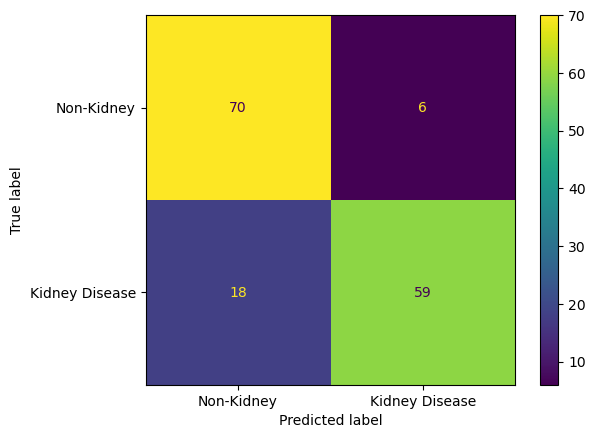

In [23]:
target = 'class'
features = ['albumin',
           'bun',
           'bicarbonate']
best_grid_cv = GridSearchCV(estimator = LogisticRegression(),
                           param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
                           scoring = 'accuracy',
                           cv = 5)
best_grid_cv.fit(data_train[features],
                data_train[target])
best_model = best_grid_cv.best_estimator_
pred_train = best_model.predict(data_train[features])
cm_train = confusion_matrix(data_train[target],
                           pred_train)
print('The best hyperparameter values were', best_grid_cv.best_params_)
print('The best average cross-validation accuracy was', best_grid_cv.best_score_)
print('The false negative rate on the training data was', cm_train[1, 0]/(cm_train[1, 1] + cm_train[1, 0]))

pred_test = best_model.predict(data_test[features])
cm_test = confusion_matrix(data_test[target],
                          pred_test)
print('\n')
print('The accuracy on the test set was', accuracy_score(data_test[target], pred_test))
print('The false negative rate on the test data was', cm_test[1, 0]/(cm_test[1, 1] + cm_test[1, 0]))
disp = ConfusionMatrixDisplay(confusion_matrix = cm_test,
                              display_labels = ['Non-Kidney',
                                               'Kidney Disease'])
disp.plot()
plt.show()

### Creatinine Model (Features: Creatinine)

In [14]:
features = ['creatinine']
creatinine_grid_cv = GridSearchCV(estimator = LogisticRegression(),
                                  param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
                                  scoring = 'accuracy',
                                  cv = 5)
creatinine_grid_cv.fit(data_train[features],
                       data_train[target])
creatinine_model = creatinine_grid_cv.best_estimator_
pred_train = creatinine_model.predict(data_train[features])
cm_train = confusion_matrix(data_train[target],
                           pred_train)
print('The best hyperparameter values were', creatinine_grid_cv.best_params_)
print('The best average cross-validation accuracy was', creatinine_grid_cv.best_score_)
print('The false negative rate on the training data was', cm_train[1, 0]/(cm_train[1, 1] + cm_train[1, 0]))

pred_test = creatinine_model.predict(data_test[features])
cm_test = confusion_matrix(data_test[target],
                          pred_test)
print('\n')
print('The accuracy on the test set was', accuracy_score(data_test[target], pred_test))
print('The false negative rate on the test data was', cm_test[1, 0]/(cm_test[1, 1] + cm_test[1, 0]))

The best hyperparameter values were {'C': 1}
The best average cross-validation accuracy was 0.9247101159536186
The false negative rate on the training data was 0.11147540983606558


The accuracy on the test set was 0.9084967320261438
The false negative rate on the test data was 0.14285714285714285
